In [1]:
import pandas as pd
df = pd.read_csv("C:\\Users\\HP\\Downloads\\iris_data (2).csv")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [5]:
avg_petal_length = df.groupby('species')['petal_length'].mean()
avg_petal_length

species
setosa        1.464
versicolor    4.260
virginica     5.552
Name: petal_length, dtype: float64

In [7]:
avg_petal_length.info()

<class 'pandas.core.series.Series'>
Index: 3 entries, setosa to virginica
Series name: petal_length
Non-Null Count  Dtype  
--------------  -----  
3 non-null      float64
dtypes: float64(1)
memory usage: 156.0+ bytes


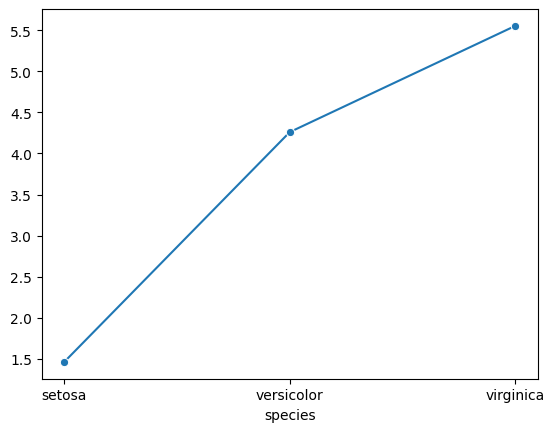

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(x=avg_petal_length.index,y= avg_petal_length.values,marker = 'o')
plt.show()

In [11]:
relation = df['sepal_length'].corr
relation_2 = df['petal_length'].corr
print(relation,relation_2)

<bound method Series.corr of 0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: sepal_length, Length: 150, dtype: float64> <bound method Series.corr of 0      1.4
1      1.4
2      1.3
3      1.5
4      1.4
      ... 
145    5.2
146    5.0
147    5.2
148    5.4
149    5.1
Name: petal_length, Length: 150, dtype: float64>


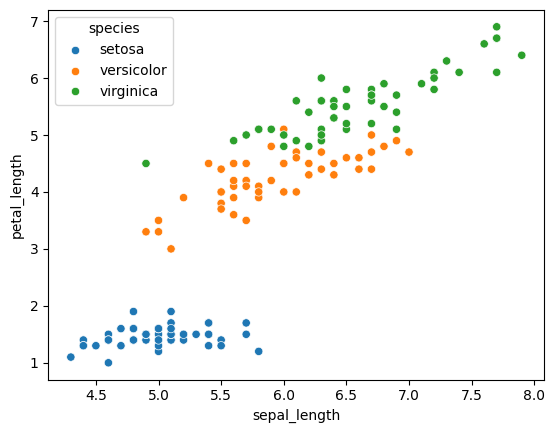

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='sepal_length', y='petal_length', hue='species', data=df)
plt.show() 

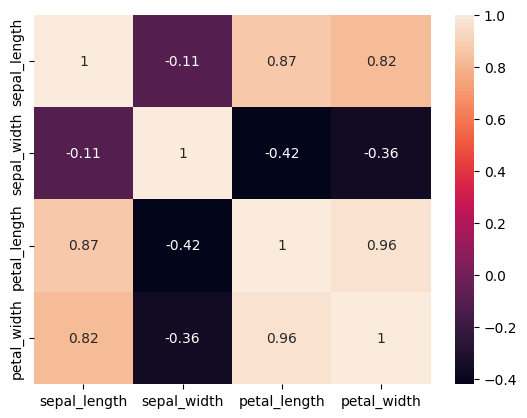

In [15]:
sns.heatmap(df.corr(numeric_only = True), annot = True)
plt.show()

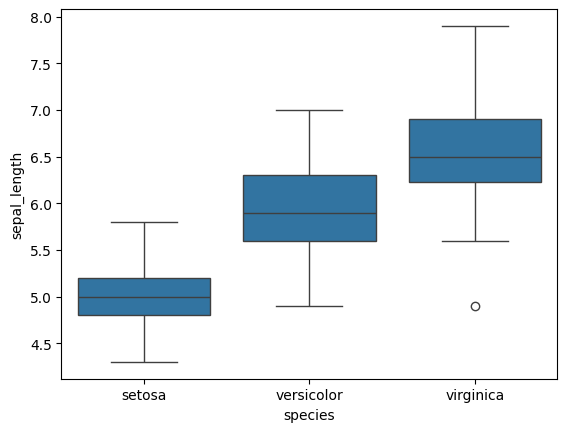

In [17]:
sns.boxplot(x='species',y='sepal_length',data=df)
plt.show()

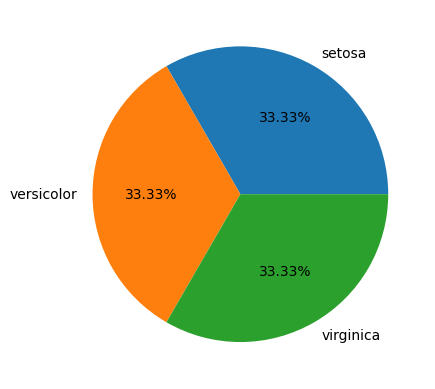

In [19]:
species_count = df['species'].value_counts()
plt.pie(species_count,labels=species_count.index,autopct='%1.2f%%')
plt.show()

# Using SKLEARN

In [22]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


In [24]:
df = pd.read_csv("C:\\Users\\HP\\Downloads\\iris_data (2).csv")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [26]:
# Normal df containns both feature and target
df_num = df.drop('species',axis = 1)  # axis means row,column to drop and 0 means row and 1 means column
df_num.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [28]:
n = MinMaxScaler()
df_normalization = pd.DataFrame(n.fit_transform(df_num),columns = df_num.columns)

In [30]:
#Standarize the data (Z-Score Scaling)
s = StandardScaler()
df_standardize = pd.DataFrame(s.fit_transform(df_num),columns = df_num.columns)
df_standardize.head()

,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


In [32]:
 # LabelEncoder
label_encoder = LabelEncoder()
df['species_encoder'] =label_encoder.fit_transform(df['species'])
print(df['species_encoder'].head())
print('============================================================================================')
df

0    0
1    0
2    0
3    0
4    0
Name: species_encoder, dtype: int32


,sepal_length,sepal_width,petal_length,petal_width,species,species_encoder
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,2
146,6.3,2.5,5.0,1.9,virginica,2
147,6.5,3.0,5.2,2.0,virginica,2
148,6.2,3.4,5.4,2.3,virginica,2


In [34]:
import pandas as pd
df = pd.read_csv('C:\\Users\\HP\\Downloads\\iris_data (2).csv')

In [36]:
onehot_encoder = OneHotEncoder(sparse_output = False)

encoded_species = pd.DataFrame(onehot_encoder.fit_transform(df[['species']]))
encoded_species

merged = pd.concat([df, encoded_species], axis=1)
merged

result = merged.drop('species',axis = 1)
result
      
    

,sepal_length,sepal_width,petal_length,petal_width,0,1,2
0,5.1,3.5,1.4,0.2,1.0,0.0,0.0
1,4.9,3.0,1.4,0.2,1.0,0.0,0.0
2,4.7,3.2,1.3,0.2,1.0,0.0,0.0
3,4.6,3.1,1.5,0.2,1.0,0.0,0.0
4,5.0,3.6,1.4,0.2,1.0,0.0,0.0
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0.0,0.0,1.0
146,6.3,2.5,5.0,1.9,0.0,0.0,1.0
147,6.5,3.0,5.2,2.0,0.0,0.0,1.0
148,6.2,3.4,5.4,2.3,0.0,0.0,1.0


In [38]:
import pandas as pd
df = pd.read_csv("C:\\Users\\HP\\Downloads\\iris_data (2).csv")

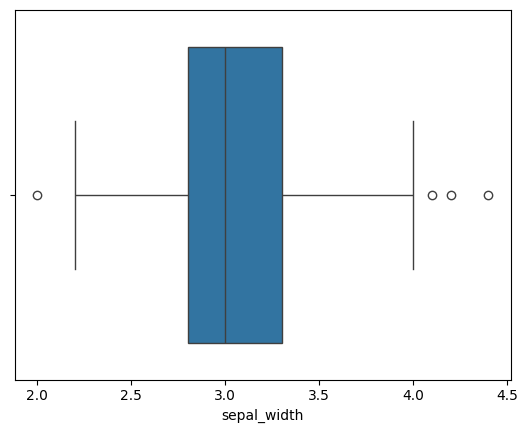

In [40]:
sns.boxplot(x='sepal_width',data = df)
plt.show()

In [42]:
Q1 = df['sepal_width'].quantile(0.25)
Q3 = df['sepal_width'].quantile(0.75)
IQR = Q3-Q1
Lower_bound = Q1 - 1.5*IQR
Upper_bound = Q3 + 1.5*IQR
df = df[(df['sepal_width'] > Lower_bound) & (df['sepal_width'] < Upper_bound)]
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


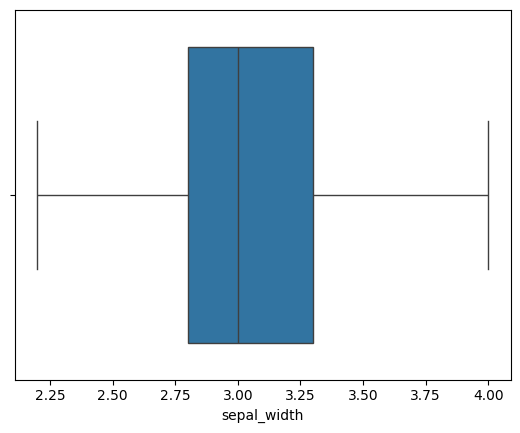

In [44]:
sns.boxplot(x='sepal_width',data = df)
plt.show()

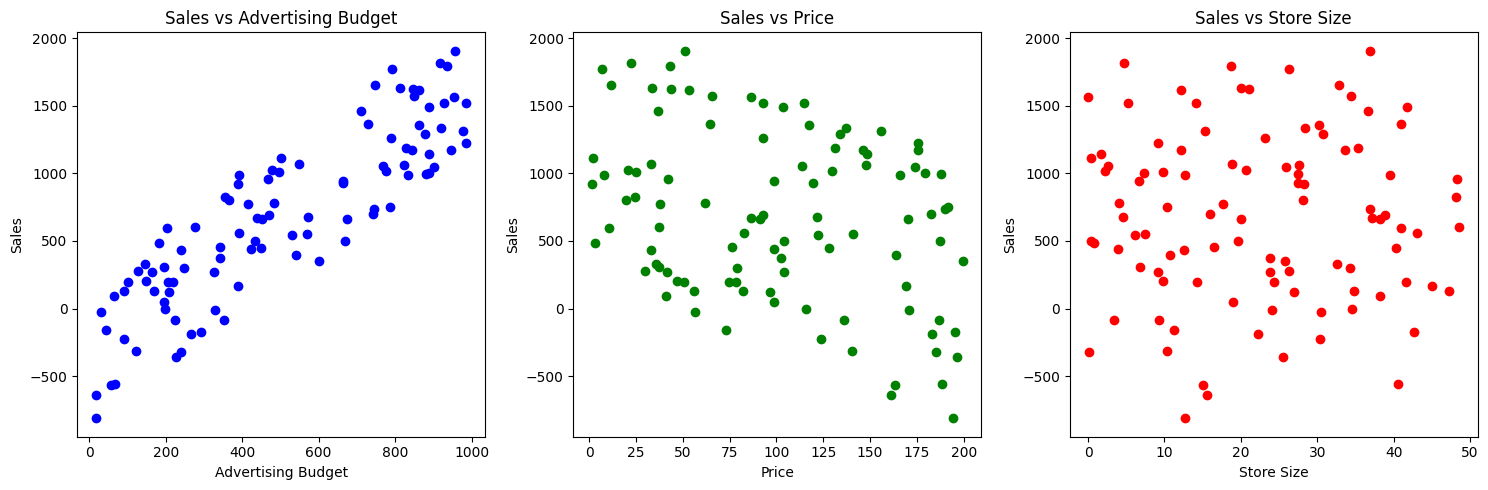

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Example Data
x1 = np.random.rand(100) * 1000  # Advertising budget
x2 = np.random.rand(100) * 200  # Price
x3 = np.random.rand(100) * 50   # Store size
y = 100 + 2 * x1 - 5 * x2 + 3 * x3 + np.random.randn(100) * 20  # Sales

# Create subplots for each independent variable
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Plot Sales vs Advertising Budget
axs[0].scatter(x1, y, color='blue', label='Advertising Budget')
axs[0].set_xlabel('Advertising Budget')
axs[0].set_ylabel('Sales')
axs[0].set_title('Sales vs Advertising Budget')

# Plot Sales vs Price
axs[1].scatter(x2, y, color='green', label='Price')
axs[1].set_xlabel('Price')
axs[1].set_ylabel('Sales')
axs[1].set_title('Sales vs Price')

# Plot Sales vs Store Size
axs[2].scatter(x3, y, color='red', label='Store Size')
axs[2].set_xlabel('Store Size')
axs[2].set_ylabel('Sales')
axs[2].set_title('Sales vs Store Size')

plt.tight_layout()
plt.show()


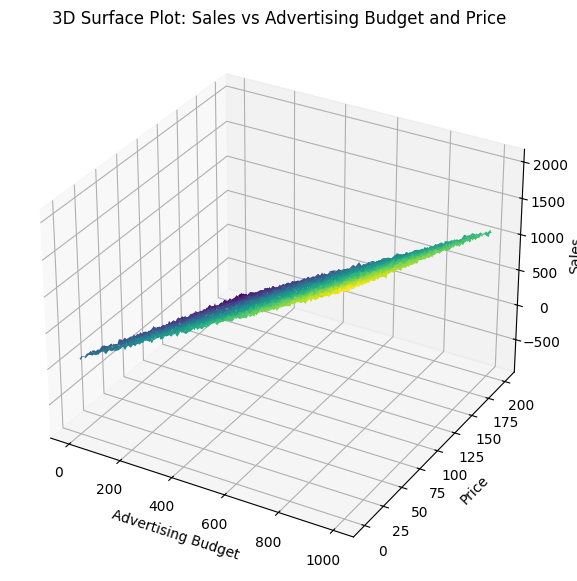

In [48]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Example data
x1 = np.linspace(0, 1000, 100)  # Advertising Budget
x2 = np.linspace(0, 200, 100)   # Price
x1, x2 = np.meshgrid(x1, x2)
y = 100 + 2*x1 - 5*x2 + np.random.randn(*x1.shape) * 20  # Sales

# Create 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(x1, x2, y, cmap='viridis')

# Labels and Title
ax.set_xlabel('Advertising Budget')
ax.set_ylabel('Price')
ax.set_zlabel('Sales')
ax.set_title('3D Surface Plot: Sales vs Advertising Budget and Price')

plt.show()
